In [1]:
import pandas as pd

from sklearn.model_selection import train_test_split

from src.preprocessing import fit_preprocessing, transform_preprocessor
from src.models import compare_models, predict_and_score

from src.utils import roc_graph

## 코드 테스트

In [2]:
# 데이터 호출
df = pd.read_csv("../../01_data/processed/model_df.csv")

In [3]:
# X/y split
X = df.drop('churned', axis=1)
y = df['churned']

# train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# tr/val split
X_tr, X_val, y_tr, y_val = train_test_split(X_train, y_train, test_size=0.1, random_state=42, stratify=y_train)

In [4]:
# 데이터 전처리 함수 호출
X_tr_prep, encoders, scaler = fit_preprocessing(X_tr)
X_val_prep = transform_preprocessor(X_val, encoders, scaler)
X_test_prep = transform_preprocessor(X_test, encoders, scaler)

In [5]:
# 약 40분 소요
models = compare_models(X_tr, X_tr_prep, X_val, X_val_prep, y_tr, y_val)

Completed models:
- LogisticRegression
- SVC
- CatBoostClassifier
- XGBClassifier
- LGBMClassifier
- RandomForestClassifier


In [6]:
# 약 18분 소요
train_scores = {}

for model in models:

    if model.__class__.__name__ == 'CatBoostClassifier':
        train_scores[model.__class__.__name__] = predict_and_score(model, X_tr, y_tr)
        continue

    train_scores[model.__class__.__name__] = predict_and_score(model, X_tr_prep, y_tr)


LogisticRegression Results
Accuracy : 0.6846
F1 Score : 0.6950
ROC AUC  : 0.7560

SVC Results
Accuracy : 0.8208
F1 Score : 0.8266
ROC AUC  : 0.9042

CatBoostClassifier Results
Accuracy : 0.8701
F1 Score : 0.8717
ROC AUC  : 0.9515

XGBClassifier Results
Accuracy : 0.8821
F1 Score : 0.8838
ROC AUC  : 0.9577

LGBMClassifier Results
Accuracy : 0.8749
F1 Score : 0.8773
ROC AUC  : 0.9538

RandomForestClassifier Results
Accuracy : 0.8113
F1 Score : 0.8149
ROC AUC  : 0.9013


In [7]:
# 약 1분 소요
val_scores = {}

for model in models:

    if model.__class__.__name__ == 'CatBoostClassifier':
        val_scores[model.__class__.__name__] = predict_and_score(model, X_val, y_val)
        continue

    val_scores[model.__class__.__name__] = predict_and_score(model, X_val_prep, y_val)


LogisticRegression Results
Accuracy : 0.6742
F1 Score : 0.6878
ROC AUC  : 0.7465

SVC Results
Accuracy : 0.7812
F1 Score : 0.7880
ROC AUC  : 0.8689

CatBoostClassifier Results
Accuracy : 0.8386
F1 Score : 0.8404
ROC AUC  : 0.9369

XGBClassifier Results
Accuracy : 0.8394
F1 Score : 0.8424
ROC AUC  : 0.9363

LGBMClassifier Results
Accuracy : 0.8412
F1 Score : 0.8446
ROC AUC  : 0.9372

RandomForestClassifier Results
Accuracy : 0.8045
F1 Score : 0.8083
ROC AUC  : 0.8949


In [8]:
# 약 4분 소요
test_scores = {}

for model in models:

    if model.__class__.__name__ == 'CatBoostClassifier':
        test_scores[model.__class__.__name__] = predict_and_score(model, X_test, y_test)
        continue

    test_scores[model.__class__.__name__] = predict_and_score(model, X_test_prep, y_test)


LogisticRegression Results
Accuracy : 0.6792
F1 Score : 0.6901
ROC AUC  : 0.7521

SVC Results
Accuracy : 0.7894
F1 Score : 0.7963
ROC AUC  : 0.8752

CatBoostClassifier Results
Accuracy : 0.8470
F1 Score : 0.8489
ROC AUC  : 0.9415

XGBClassifier Results
Accuracy : 0.8493
F1 Score : 0.8519
ROC AUC  : 0.9416

LGBMClassifier Results
Accuracy : 0.8490
F1 Score : 0.8519
ROC AUC  : 0.9420

RandomForestClassifier Results
Accuracy : 0.8120
F1 Score : 0.8161
ROC AUC  : 0.9004


In [9]:
train_scores_df = pd.DataFrame(train_scores).T[['accuracy','f1','roc_auc']]
train_scores_df

,accuracy,f1,roc_auc
LogisticRegression,0.684556,0.695046,0.755951
SVC,0.820767,0.826591,0.904211
CatBoostClassifier,0.870111,0.871702,0.951548
XGBClassifier,0.882089,0.883809,0.957682
LGBMClassifier,0.874944,0.877261,0.953789
RandomForestClassifier,0.811289,0.814945,0.901312


In [10]:
val_scores_df = pd.DataFrame(val_scores).T[['accuracy','f1','roc_auc']]
val_scores_df

,accuracy,f1,roc_auc
LogisticRegression,0.6742,0.687752,0.746479
SVC,0.7812,0.787984,0.868857
CatBoostClassifier,0.8386,0.840419,0.936932
XGBClassifier,0.8394,0.842425,0.936306
LGBMClassifier,0.8412,0.844618,0.937171
RandomForestClassifier,0.8045,0.808277,0.894896


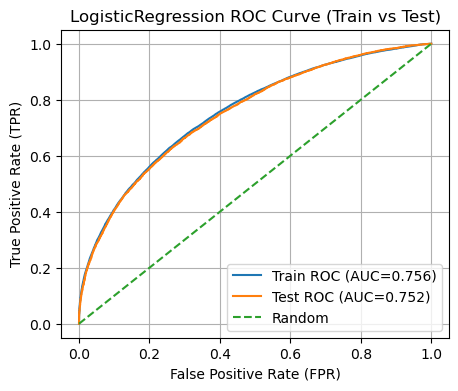

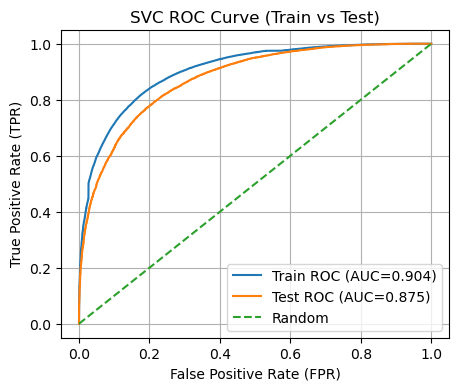

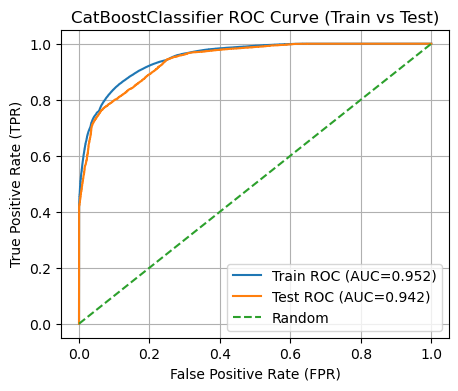

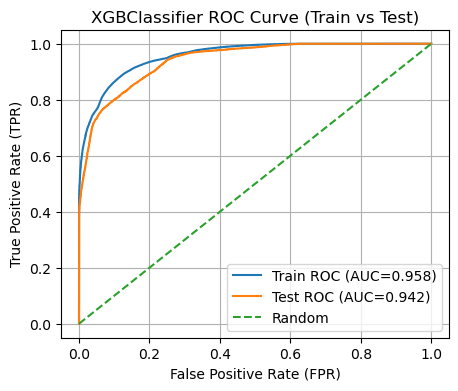

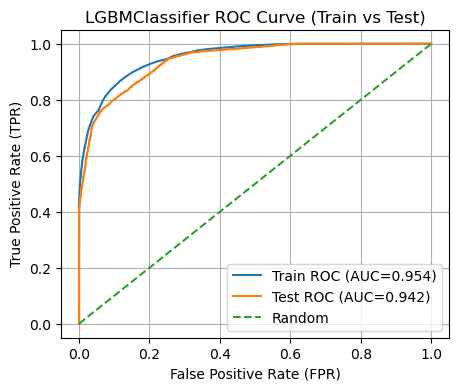

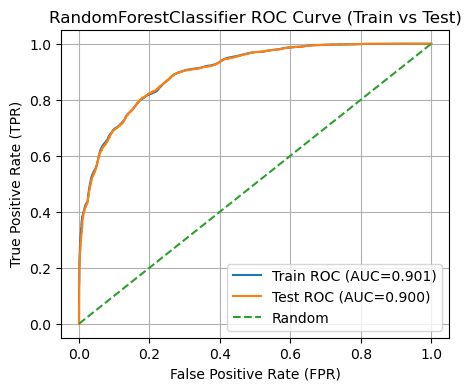

In [12]:
for model in models:

    name = model.__class__.__name__
    y_train_pred = train_scores[name]['y_proba']
    y_test_pred = val_scores[name]['y_proba']

    roc_graph(name, y_tr, y_train_pred, y_test, y_test_pred)